# 🔫 Deadlock Optimal Build Recommender

This notebook trains a **sequence model** that recommends the optimal item build order for a given hero and rank tier in Deadlock, using live data from the [Deadlock API](https://deadlock-api.com).

## Architecture Overview

```
Deadlock API
  ├── /v1/analytics/item-stats          → item win rates by hero, buy_time, net_worth
  ├── /v1/analytics/item-permutation-stats → ordered item combo win rates
  ├── /v1/analytics/ability-order-stats → ability upgrade sequences
  └── assets.deadlock-api.com/v1/items  → item metadata (name, cost, category)

Pipeline
  1. Data Collection   → fetch & cache API data per hero × rank
  2. Sequence Building → convert per-item stats into (sequence, win) training examples
  3. Model Training    → GRU sequence model predicts P(win | items_so_far, hero, rank)
  4. Beam Search       → decode the highest-EV build path step-by-step
  5. Evaluation        → compare recommended builds against observed top win-rate builds
```

## Key Design Decisions

- We treat build recommendation as **sequential decision-making**: at each gold breakpoint, the model picks the next best item given what's already been bought.
- We use the `game_time_min` bucket from `item-stats` to get buy-time distributions, giving us temporal ordering signal without needing raw match replays.
- The `item-permutation-stats` endpoint gives win rates for item *combinations*, which encodes synergy between items directly into our training labels.
- We condition on `hero_id` and `min_badge_level` (rank) so recommendations are rank-appropriate.


---
## 0. Setup & Dependencies

In [1]:
# Install required packages (run once)
# %pip install requests pandas numpy torch scikit-learn tqdm matplotlib seaborn

In [6]:
import requests
import pandas as pd
import numpy as np
import json
import time
import os
from pathlib import Path
from tqdm.auto import tqdm as tqdm
import tqdm as tqdm_module
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split

# ── Config ──────────────────────────────────────────────────────────────────
BASE_API   = "https://api.deadlock-api.com"
ASSETS_API = "https://api.deadlock-api.com/v1/assets"
CACHE_DIR  = Path("./data_cache")
CACHE_DIR.mkdir(exist_ok=True)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {DEVICE}")

# Rank tiers: badge_level maps to Deadlock's rank system
# 0=Obscurus, 1=Seeker, 2=Alchemist, 3=Arcanist, 4=Ritualist,
# 5=Emissary, 6=Archon, 7=Oracle, 8=Phantom, 9=Ascendant, 10=Eternus
RANK_TIERS = {
    "low":  (0, 4),   # Obscurus → Ritualist
    "mid":  (5, 7),   # Emissary → Oracle
    "high": (8, 11),  # Phantom → Eternus
}

Using device: cuda


---
## 1. Data Collection

In [11]:
def cached_get(url: str, params: dict = None, cache_key: str = None, ttl_hours: int = 24) -> dict:
    """Fetch JSON from URL with local file cache to avoid hammering the API."""
    if cache_key is None:
        cache_key = url.replace("/", "_").replace(":", "") + str(params)
    cache_file = CACHE_DIR / f"{cache_key}.json"

    if cache_file.exists():
        age_hours = (time.time() - cache_file.stat().st_mtime) / 3600
        if age_hours < ttl_hours:
            return json.loads(cache_file.read_text())

    resp = requests.get(url, params=params, timeout=30)
    resp.raise_for_status()
    data = resp.json()
    cache_file.write_text(json.dumps(data))
    time.sleep(0.3)  # polite rate limiting
    return data


def fetch_heroes() -> pd.DataFrame:
    """Fetch all hero metadata from the Assets API."""
    data = cached_get(f"{ASSETS_API}/heroes", cache_key="heroes")
    heroes = [{"hero_id": h["id"], "name": h["name"], "class": h.get("hero_class", "unknown")}
              for h in data
                if (
                    h.get("player_selectable") is True
                    and not h.get("disabled")
                    and not h.get("in_development")
                    and not h.get("assigned_players_only")
                    and not h.get("limited_testing")
                )]
    return pd.DataFrame(heroes)


def fetch_items() -> pd.DataFrame:
    """Fetch all shop items from the Assets API, by slot type."""
    items = []
    for slot in ("weapon", "vitality", "spirit"):
        data = cached_get(f"{ASSETS_API}/items/by-slot-type/{slot}", cache_key=f"items_{slot}")
        for item in data:
            if item.get("disabled"):
                continue
            items.append({
                "item_id":  item["id"],
                "name":     item["name"],
                "cost":     item.get("cost", 0),
                "category": slot,
            })
    return pd.DataFrame(items)


def fetch_item_stats_by_hero(
    hero_id: int,
    min_badge: int = 0,
    max_badge: int = 11,
    bucket: str = "game_time_min",
) -> pd.DataFrame:
    """
    Fetch item win/loss stats for a specific hero, bucketed by game-time minute.
    This gives us: for each item × minute bucket → wins, losses, pick_rate.
    Params:
      bucket: 'game_time_min' gives temporal ordering signal.
              'net_worth_by_3000' gives economy-gated signal.
    """
    params = {
        "hero_id":         hero_id,
        "min_badge_level": min_badge,
        "max_badge_level": max_badge,
        "bucket":          bucket,
    }
    key = f"item_stats_hero{hero_id}_badge{min_badge}_{max_badge}_bucket_{bucket}"
    data = cached_get(f"{BASE_API}/v1/analytics/item-stats", params=params, cache_key=key)
    if not data:
        return pd.DataFrame()
    df = pd.DataFrame(data)
    df["hero_id"]    = hero_id
    df["min_badge"]  = min_badge
    df["max_badge"]  = max_badge
    df["win_rate"]   = df["wins"] / (df["wins"] + df["losses"]).clip(lower=1)
    return df


def fetch_item_permutation_stats(
    hero_id: int,
    min_badge: int = 0,
    max_badge: int = 11,
) -> pd.DataFrame:
    """
    Fetch win rates for ordered item combinations (permutations).
    This is the richest signal for sequence modeling — it tells us
    how item A → item B performs vs. item B → item A.
    """
    params = {
        "hero_id":         hero_id,
        "min_badge_level": min_badge,
        "max_badge_level": max_badge,
    }
    key = f"item_perm_hero{hero_id}_badge{min_badge}_{max_badge}"
    data = cached_get(f"{BASE_API}/v1/analytics/item-permutation-stats", params=params, cache_key=key)
    if not data:
        return pd.DataFrame()
    df = pd.DataFrame(data)
    df["hero_id"]  = hero_id
    df["win_rate"] = df["wins"] / (df["wins"] + df["losses"]).clip(lower=1)
    return df


print("Fetching hero and item metadata...")
heroes_df = fetch_heroes()
items_df  = fetch_items()
print(f"Heroes: {len(heroes_df)} | Items: {len(items_df)}")
display(heroes_df.head())
display(items_df.head())

Fetching hero and item metadata...


HTTPError: 502 Server Error: Bad Gateway for url: https://api.deadlock-api.com/v1/assets/items/by-slot-type/spirit

In [ ]:
# ── Pick which heroes & rank tier to train on ────────────────────────────────
# Start with a subset for quick iteration; set to heroes_df["hero_id"].tolist() for full training.
TARGET_HERO_IDS = heroes_df["hero_id"].tolist()[:10]  # first 10 heroes
RANK_TIER = "mid"  # "low" | "mid" | "high"
min_badge, max_badge = RANK_TIERS[RANK_TIER]

print(f"Training on rank tier: {RANK_TIER} (badge {min_badge}–{max_badge})")
print(f"Target heroes: {TARGET_HERO_IDS}")

# ── Fetch all item stats ─────────────────────────────────────────────────────
all_item_stats = []
all_perm_stats  = []

for hero_id in tqdm(TARGET_HERO_IDS, desc="Fetching item stats"):
    try:
        stats = fetch_item_stats_by_hero(hero_id, min_badge, max_badge, bucket="game_time_min")
        if not stats.empty:
            all_item_stats.append(stats)
    except Exception as e:
        print(f"Skipping hero {hero_id} item stats: {e}")

    try:
        perms = fetch_item_permutation_stats(hero_id, min_badge, max_badge)
        if not perms.empty:
            all_perm_stats.append(perms)
    except Exception as e:
        print(f"Skipping hero {hero_id} perm stats: {e}")

item_stats_df = pd.concat(all_item_stats, ignore_index=True)
perm_stats_df = pd.concat(all_perm_stats, ignore_index=True)

print(f"\nItem stats rows: {len(item_stats_df):,}")
print(f"Permutation stats rows: {len(perm_stats_df):,}")
display(item_stats_df.head())

Training on rank tier: mid (badge 5–7)
Target heroes: [1, 2, 3, 4, 6, 7, 8, 10, 11, 12]


Fetching item stats:  60%|██████    | 6/10 [00:00<00:00,  8.44it/s]

Skipping hero 8 item stats: 500 Server Error: Internal Server Error for url: https://api.deadlock-api.com/v1/analytics/item-stats?hero_id=8&min_badge_level=5&max_badge_level=7&bucket=game_time_min


Fetching item stats:  90%|█████████ | 9/10 [00:44<00:06,  6.98s/it]

Skipping hero 10 item stats: 500 Server Error: Internal Server Error for url: https://api.deadlock-api.com/v1/analytics/item-stats?hero_id=10&min_badge_level=5&max_badge_level=7&bucket=game_time_min


In [ ]:
display(perm_stats_df.head())

,item_ids,wins,losses,matches,hero_id,win_rate
0,"[7409189, 876563814]",271168,246691,517859,1,0.523633
1,"[7409189, 2717651715]",273038,243672,516710,1,0.528416
2,"[968099481, 7409189]",255627,235640,491267,1,0.520342
3,"[968099481, 876563814]",242172,219154,461326,1,0.524948
4,"[2951612397, 2717651715]",240564,218756,459320,1,0.523739


In [ ]:
print(perm_stats_df["item_ids"].apply(len).value_counts())

item_ids
2    227439
Name: count, dtype: int64


---
## 2. Exploratory Data Analysis

In [28]:
# Top 15 items by total matches for this hero
top_items = (
    item_stats_df[item_stats_df["hero_id"] == EXAMPLE_HERO_ID]
    .groupby("item_id")["matches"].sum()
    .nlargest(15)
    .index
)

# Bin minutes into game phases
def phase(bucket):
    if bucket <= 10: return "Early (0-10m)"
    elif bucket <= 20: return "Mid (11-20m)"
    elif bucket <= 30: return "Late (21-30m)"
    else: return "Very Late (30m+)"

hero_time = (
    item_stats_df[
        (item_stats_df["hero_id"] == EXAMPLE_HERO_ID) &
        (item_stats_df["item_id"].isin(top_items))
    ]
    .merge(items_df[["item_id", "name"]], on="item_id", how="left")
    .assign(phase=lambda d: d["bucket"].apply(phase))
    .groupby(["name", "phase"])["win_rate"].mean()
    .unstack("phase")
    .reindex(columns=["Early (0-10m)", "Mid (11-20m)", "Late (21-30m)", "Very Late (30m+)"])
)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(hero_time, cmap="RdYlGn", center=0.5, ax=ax,
            annot=True, fmt=".2f", linewidths=0.5)
ax.set_title(f"Win Rate by Game Phase — {hero_name} (top 15 items)")
ax.set_xlabel("")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

NameError: name 'EXAMPLE_HERO_ID' is not defined

---
## 3. Dataset Construction

We construct **synthetic build sequences** from the permutation stats.
Each training example is:
```
Input:  [hero_id, rank_tier, item_1, item_2, ..., item_k]   (items bought so far)
Target: item_{k+1}                                          (next item to buy)
Label:  win_rate of the full permutation                    (used as sample weight)
```

This turns the problem into a **next-item prediction** task — analogous to next-token prediction in language models, but conditioned on hero and rank.

In [16]:
# ── Vocabulary ───────────────────────────────────────────────────────────────
# Build integer indices for items, heroes, and rank tiers

ALL_ITEM_IDS  = sorted(items_df["item_id"].unique().tolist())
ALL_HERO_IDS  = sorted(heroes_df["hero_id"].unique().tolist())
RANK_TIER_IDS = ["low", "mid", "high"]

PAD_IDX = 0
item2idx  = {iid: i+1 for i, iid in enumerate(ALL_ITEM_IDS)}   # 1-indexed; 0=PAD
idx2item  = {v: k for k, v in item2idx.items()}
hero2idx  = {hid: i   for i, hid in enumerate(ALL_HERO_IDS)}
rank2idx  = {r: i     for i, r  in enumerate(RANK_TIER_IDS)}

N_ITEMS = len(ALL_ITEM_IDS) + 1   # +1 for PAD
N_HEROES = len(ALL_HERO_IDS)
N_RANKS  = len(RANK_TIER_IDS)

print(f"Vocabulary: {N_ITEMS} items | {N_HEROES} heroes | {N_RANKS} ranks")

Vocabulary: 188 items | 38 heroes | 3 ranks


In [17]:
def build_sequences_from_permutations(perm_df, rank_tier, max_chain_len=16):
    from collections import defaultdict

    rank_idx = rank2idx[rank_tier]
    examples = []

    # Group pair win rates by hero
    for hero_id, hero_perms in perm_df.groupby("hero_id"):
        hero_idx = hero2idx.get(hero_id)
        if hero_idx is None:
            continue

        # Build adjacency: next_item -> list of (prev_item, win_rate, total)
        graph = defaultdict(list)
        for _, row in hero_perms.iterrows():
            a, b = row["item_ids"]
            if a not in item2idx or b not in item2idx:
                continue
            total = row["wins"] + row["losses"]
            if total < 20:
                continue
            graph[item2idx[a]].append((item2idx[b], float(row["win_rate"]), total))

        # Build early-game seed items for this hero (bought before minute 10)
        early_items = (
            item_stats_df[
                (item_stats_df["hero_id"] == hero_id) &
                (item_stats_df["bucket"] <= 10)
            ]
            .groupby("item_id")["win_rate"].mean()
            .sort_values(ascending=False)
            .head(20)
            .index.tolist()
        )
        early_idxs = [item2idx[i] for i in early_items if i in item2idx]

        seeds = early_idxs + [i for i in graph.keys() if i not in set(early_idxs)]
        for start_idx in seeds:
            chain = [start_idx]
            visited = {start_idx}
            for _ in range(max_chain_len - 1):
                neighbors = [
                    (nxt, wr, tot) for nxt, wr, tot in graph.get(chain[-1], [])
                    if nxt not in visited
                ]
                if not neighbors:
                    break
                # Pick highest win-rate next item
                best = max(neighbors, key=lambda x: x[1])
                chain.append(best[0])
                visited.add(best[0])

            if len(chain) < 2:
                continue

            # Sort chain by item cost (early cheap items first)
            item_costs = items_df.set_index("item_id")["cost"]
            chain.sort(key=lambda idx: item_costs.get(idx2item.get(idx, 0), 0))


            # Emit one training example per prefix
            chain_wr = sum(
                graph[chain[i]][0][1] for i in range(len(chain)-1)
                if graph.get(chain[i])
                ) / max(len(chain)-1, 1)
            for k in range(1, len(chain)):
                examples.append({
                    "hero_idx": hero_idx,
                    "rank_idx": rank_idx,
                    "context":  chain[:k],
                    "target":   chain[k],
                    "win_rate": chain_wr,
                    "total":    100,
                })

    return examples


print("Building training sequences from permutation stats...")
examples = build_sequences_from_permutations(perm_stats_df, RANK_TIER)
print(f"Training examples: {len(examples):,}")

if examples:
    sample = examples[0]
    print(f"\nSample example:")
    print(f"  hero_idx={sample['hero_idx']}  rank_idx={sample['rank_idx']}")
    print(f"  context={sample['context']}  target={sample['target']}")
    print(f"  win_rate={sample['win_rate']:.3f}  total={sample['total']}")

Building training sequences from permutation stats...
Training examples: 20,827

Sample example:
  hero_idx=0  rank_idx=1
  context=[186]  target=35
  win_rate=0.563  total=100


In [19]:
# ── PyTorch Dataset ──────────────────────────────────────────────────────────
MAX_SEQ_LEN = 16  # max items in a build we model (Deadlock has 12 item slots)


class BuildDataset(Dataset):
    def __init__(self, examples: list[dict], max_seq_len: int = MAX_SEQ_LEN):
        self.examples    = examples
        self.max_seq_len = max_seq_len

    def __len__(self):
        return len(self.examples)

    def __getitem__(self, idx):
        ex = self.examples[idx]

        # Pad or truncate context
        ctx = ex["context"][-self.max_seq_len:]  # keep most recent
        pad_len = self.max_seq_len - len(ctx)
        ctx_padded = [PAD_IDX] * pad_len + ctx

        return {
            "hero":     torch.tensor(ex["hero_idx"], dtype=torch.long),
            "rank":     torch.tensor(ex["rank_idx"], dtype=torch.long),
            "context":  torch.tensor(ctx_padded,    dtype=torch.long),
            "seq_len":  torch.tensor(len(ctx),       dtype=torch.long),
            "target":   torch.tensor(ex["target"],  dtype=torch.long),
            "weight":   torch.tensor(ex["win_rate"], dtype=torch.float),
        }


# Train / val split
train_ex, val_ex = train_test_split(examples, test_size=0.15, random_state=42)
train_ds = BuildDataset(train_ex)
val_ds   = BuildDataset(val_ex)

train_loader = DataLoader(train_ds, batch_size=256, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_ds,   batch_size=256, shuffle=False, num_workers=0)

print(f"Train: {len(train_ds):,} examples | Val: {len(val_ds):,} examples")

Train: 17,702 examples | Val: 3,125 examples


---
## 4. Model Architecture

We use a **GRU-based sequence model** with hero and rank embeddings:

```
                     ┌──────────┐
hero_id ──Embed──►   │          │
rank_id ──Embed──►   │  concat  │──► GRU ──► Linear ──► logits (N_ITEMS)
items   ──Embed──►   │          │
                     └──────────┘
```

- Item embeddings are summed over the context window into a sequence fed to the GRU
- Hero and rank embeddings are concatenated to the GRU input at every step
- Output is a probability distribution over all items (next-item prediction)
- Loss is **weighted cross-entropy**: sequences from high win-rate builds contribute more to the gradient

In [20]:
class BuildRecommender(nn.Module):
    def __init__(
        self,
        n_items:     int,
        n_heroes:    int,
        n_ranks:     int,
        item_dim:    int = 128,
        hero_dim:    int = 64,
        rank_dim:    int = 8,
        gru_hidden:  int = 128,
        gru_layers:  int = 2,
        dropout:     float = 0.2,
    ):
        super().__init__()
        self.item_emb  = nn.Embedding(n_items,  item_dim,  padding_idx=PAD_IDX)
        self.hero_emb  = nn.Embedding(n_heroes, hero_dim)
        self.rank_emb  = nn.Embedding(n_ranks,  rank_dim)

        gru_input_dim = item_dim + hero_dim + rank_dim
        self.gru = nn.GRU(
            input_size=gru_input_dim,
            hidden_size=gru_hidden,
            num_layers=gru_layers,
            batch_first=True,
            dropout=dropout if gru_layers > 1 else 0.0,
        )
        self.dropout = nn.Dropout(dropout)
        self.head = nn.Sequential(
            nn.Linear(gru_hidden, gru_hidden),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(gru_hidden, n_items),
        )

    def forward(self, hero, rank, context, seq_len):
        """
        hero:    (B,)         hero index
        rank:    (B,)         rank tier index
        context: (B, T)       item indices (padded)
        seq_len: (B,)         actual sequence lengths
        Returns: (B, N_ITEMS) logits
        """
        B, T = context.shape

        item_e = self.item_emb(context)                          # (B, T, item_dim)
        hero_e = self.hero_emb(hero).unsqueeze(1).expand(B, T, -1)  # (B, T, hero_dim)
        rank_e = self.rank_emb(rank).unsqueeze(1).expand(B, T, -1)  # (B, T, rank_dim)

        x = torch.cat([item_e, hero_e, rank_e], dim=-1)          # (B, T, gru_input_dim)

        # Pack to skip padding in GRU
        packed = nn.utils.rnn.pack_padded_sequence(
            x, seq_len.cpu().clamp(min=1), batch_first=True, enforce_sorted=False
        )
        _, hidden = self.gru(packed)                             # hidden: (layers, B, H)
        last_hidden = self.dropout(hidden[-1])                   # (B, H)

        logits = self.head(last_hidden)                          # (B, N_ITEMS)
        return logits


model = BuildRecommender(
    n_items=N_ITEMS, n_heroes=N_HEROES, n_ranks=N_RANKS
).to(DEVICE)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Model parameters: {total_params:,}")
print(model)

Model parameters: 293,076
BuildRecommender(
  (item_emb): Embedding(188, 128, padding_idx=0)
  (hero_emb): Embedding(38, 64)
  (rank_emb): Embedding(3, 8)
  (gru): GRU(200, 128, num_layers=2, batch_first=True, dropout=0.2)
  (dropout): Dropout(p=0.2, inplace=False)
  (head): Sequential(
    (0): Linear(in_features=128, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=128, out_features=188, bias=True)
  )
)


---
## 5. Training

In [21]:
def weighted_cross_entropy(logits, targets, weights):
    """
    Cross-entropy loss where each example is weighted by the win_rate
    of the sequence it comes from.  High-WR builds exert more gradient.
    """
    loss_per_example = F.cross_entropy(logits, targets, reduction="none")
    # Normalize weights in the batch
    w = weights / weights.sum().clamp(min=1e-8)
    return (loss_per_example * w).sum()


def train_epoch(model, loader, optimizer, scheduler=None):
    model.train()
    total_loss, n_correct, n_total = 0.0, 0, 0

    for batch in loader:
        hero    = batch["hero"].to(DEVICE)
        rank    = batch["rank"].to(DEVICE)
        context = batch["context"].to(DEVICE)
        seq_len = batch["seq_len"].to(DEVICE)
        target  = batch["target"].to(DEVICE)
        weight  = batch["weight"].to(DEVICE)

        optimizer.zero_grad()
        logits = model(hero, rank, context, seq_len)
        loss   = weighted_cross_entropy(logits, target, weight)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        if scheduler:
            scheduler.step()

        total_loss += loss.item()
        preds = logits.argmax(dim=-1)
        n_correct += (preds == target).sum().item()
        n_total   += len(target)

    return total_loss / len(loader), n_correct / n_total


@torch.no_grad()
def eval_epoch(model, loader):
    model.eval()
    total_loss, n_correct, n_total = 0.0, 0, 0

    for batch in loader:
        hero    = batch["hero"].to(DEVICE)
        rank    = batch["rank"].to(DEVICE)
        context = batch["context"].to(DEVICE)
        seq_len = batch["seq_len"].to(DEVICE)
        target  = batch["target"].to(DEVICE)
        weight  = batch["weight"].to(DEVICE)

        logits = model(hero, rank, context, seq_len)
        loss   = weighted_cross_entropy(logits, target, weight)

        total_loss += loss.item()
        preds = logits.argmax(dim=-1)
        n_correct += (preds == target).sum().item()
        n_total   += len(target)

    return total_loss / len(loader), n_correct / n_total


print("Training loop defined. Ready to train.")

Training loop defined. Ready to train.


In [22]:
N_EPOCHS = 30
LR = 3e-4

optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=N_EPOCHS * len(train_loader))

history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
best_val_loss = float("inf")

for epoch in range(1, N_EPOCHS + 1):
    tr_loss, tr_acc = train_epoch(model, train_loader, optimizer, scheduler)
    va_loss, va_acc = eval_epoch(model, val_loader)

    history["train_loss"].append(tr_loss)
    history["val_loss"].append(va_loss)
    history["train_acc"].append(tr_acc)
    history["val_acc"].append(va_acc)

    if va_loss < best_val_loss:
        best_val_loss = va_loss
        torch.save(model.state_dict(), "best_model.pt")

    if epoch % 5 == 0 or epoch == 1:
        print(f"Epoch {epoch:3d}/{N_EPOCHS} | "
              f"Train loss={tr_loss:.4f} acc={tr_acc:.3f} | "
              f"Val   loss={va_loss:.4f} acc={va_acc:.3f}")

print(f"\nBest val loss: {best_val_loss:.4f}")

Epoch   1/30 | Train loss=4.7874 acc=0.035 | Val   loss=4.2486 acc=0.048
Epoch   5/30 | Train loss=3.1261 acc=0.175 | Val   loss=2.9961 acc=0.215
Epoch  10/30 | Train loss=2.7225 acc=0.256 | Val   loss=2.6367 acc=0.273
Epoch  15/30 | Train loss=2.5480 acc=0.291 | Val   loss=2.4966 acc=0.312
Epoch  20/30 | Train loss=2.4664 acc=0.318 | Val   loss=2.4354 acc=0.321
Epoch  25/30 | Train loss=2.4339 acc=0.328 | Val   loss=2.4094 acc=0.333
Epoch  30/30 | Train loss=2.4188 acc=0.329 | Val   loss=2.4060 acc=0.334

Best val loss: 2.4060


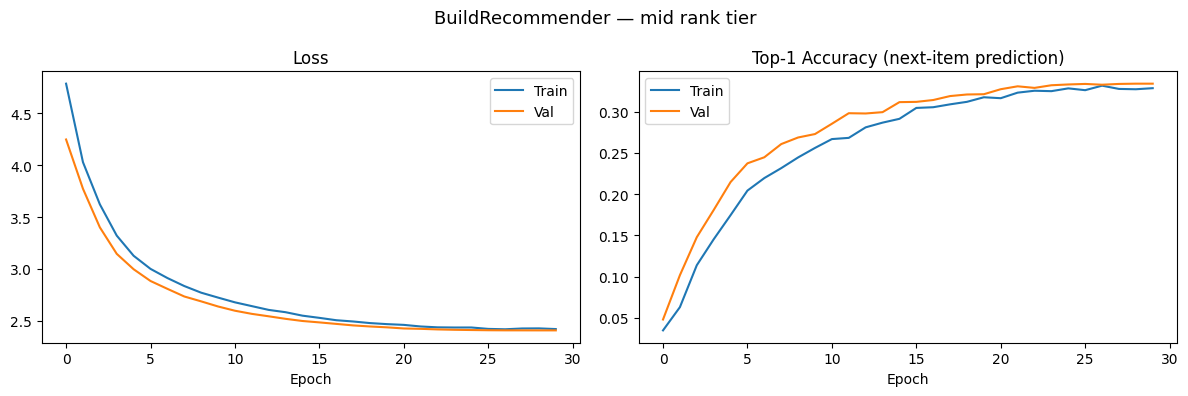

In [23]:
# ── Plot training curves ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history["train_loss"], label="Train")
axes[0].plot(history["val_loss"],   label="Val")
axes[0].set_title("Loss")
axes[0].set_xlabel("Epoch")
axes[0].legend()

axes[1].plot(history["train_acc"], label="Train")
axes[1].plot(history["val_acc"],   label="Val")
axes[1].set_title("Top-1 Accuracy (next-item prediction)")
axes[1].set_xlabel("Epoch")
axes[1].legend()

plt.suptitle(f"BuildRecommender — {RANK_TIER} rank tier", fontsize=13)
plt.tight_layout()
plt.show()

---
## 6. Inference: Beam Search Build Generation

At inference time we use **beam search** to decode the full build rather than greedy next-item prediction. This lets the model look ahead and avoid locally-optimal but globally-suboptimal choices (e.g. buying a cheap item now that blocks a stronger item later).

In [24]:
# Load best checkpoint
model.load_state_dict(torch.load("best_model.pt", map_location=DEVICE,weights_only=True))
model.eval()


@torch.no_grad()
def beam_search_build(
    hero_id:    int,
    rank_tier:  str,
    n_items:    int  = 6,
    beam_width: int  = 5,
    blocked:    list = None,   # item IDs to exclude (e.g. already bought)
) -> list[dict]:
    """
    Generate the top-`beam_width` complete builds for a hero + rank combination.

    Returns a list of dicts:
      { 'items': [item_id, ...], 'log_prob': float }
    sorted by descending log probability.
    """
    hero_idx = hero2idx.get(hero_id)
    rank_idx = rank2idx.get(rank_tier)
    if hero_idx is None or rank_idx is None:
        raise ValueError(f"Unknown hero_id={hero_id} or rank_tier={rank_tier}")

    blocked_idxs = set(item2idx[i] for i in (blocked or []) if i in item2idx)

    def score_next(context_idxs):
        """Return log-probs over next items given current context."""
        seq = context_idxs[-MAX_SEQ_LEN:]
        pad_len = MAX_SEQ_LEN - len(seq)
        ctx_t = torch.tensor([[PAD_IDX] * pad_len + seq], dtype=torch.long, device=DEVICE)
        len_t = torch.tensor([len(seq)], dtype=torch.long, device=DEVICE)
        h_t   = torch.tensor([hero_idx], dtype=torch.long, device=DEVICE)
        r_t   = torch.tensor([rank_idx], dtype=torch.long, device=DEVICE)
        logits = model(h_t, r_t, ctx_t, len_t)[0]       # (N_ITEMS,)
        log_probs = F.log_softmax(logits, dim=-1)
        return log_probs

    # Beam: list of (log_prob, [item_idx, ...])
    beams = [(0.0, [])]

    for step in range(n_items):
        candidates = []
        for log_prob, seq in beams:
            next_log_probs = score_next(seq).cpu().numpy()
            # Mask already-chosen items and blocked items
            mask = set(seq) | blocked_idxs | {PAD_IDX}
            for idx in mask:
                next_log_probs[idx] = -1e9
            # Take top beam_width candidates
            top_idxs = np.argsort(next_log_probs)[::-1][:beam_width]
            for nxt in top_idxs:
                candidates.append((log_prob + next_log_probs[nxt], seq + [int(nxt)]))
        # Prune to best beam_width
        beams = sorted(candidates, key=lambda x: -x[0])[:beam_width]

    # Convert indices back to item IDs
    results = []
    for log_prob, seq in beams:
        item_ids = [idx2item.get(idx) for idx in seq if idx in idx2item]
        results.append({"items": item_ids, "log_prob": log_prob})

    return results


print("Beam search ready.")

Beam search ready.


In [25]:
def print_build(build: dict, items_df: pd.DataFrame):
    """Pretty-print a recommended build."""
    item_info = items_df.set_index("item_id")
    print(f"  Score (log-prob): {build['log_prob']:.3f}")
    for i, iid in enumerate(build["items"], 1):
        if iid and iid in item_info.index:
            row = item_info.loc[iid]
            print(f"  {i}. [{row['category']:8s}] {row['name']:30s}  cost={int(row['cost'])}")
        else:
            print(f"  {i}. item_id={iid} (metadata not found)")
    print()


# ── Example: generate build for a hero ──────────────────────────────────────
QUERY_HERO_ID  = TARGET_HERO_IDS[0]
QUERY_RANK     = RANK_TIER

hero_name = heroes_df.loc[heroes_df["hero_id"] == QUERY_HERO_ID, "name"].values[0]
print(f"Recommended builds for {hero_name} ({QUERY_RANK} rank)\n" + "═"*50)

builds = beam_search_build(
    hero_id   = QUERY_HERO_ID,
    rank_tier = QUERY_RANK,
    n_items   = 16,
    beam_width= 2,
)

for rank, build in enumerate(builds, 1):
    print(f"Build #{rank}:")
    print_build(build, items_df)

Recommended builds for Infernus (mid rank)
══════════════════════════════════════════════════
Build #1:
  Score (log-prob): -28.003
  1. [vitality] Extra Stamina                   cost=800
  2. [spirit  ] Bullet Resist Shredder          cost=1600
  3. [spirit  ] Compress Cooldown               cost=1600
  4. [weapon  ] Recharging Rush                 cost=1600
  5. [vitality] Warp Stone                      cost=3200
  6. [weapon  ] Burst Fire                      cost=3200
  7. [vitality] Majestic Leap                   cost=3200
  8. [spirit  ] Echo Shard                      cost=6400
  9. [spirit  ] Scourge                         cost=6400
  10. [weapon  ] Crushing Fists                  cost=6400
  11. [spirit  ] Transcendent Cooldown           cost=6400
  12. [vitality] Unstoppable                     cost=6400
  13. [spirit  ] Mystic Reverb                   cost=6400
  14. [vitality] Phantom Strike                  cost=6400
  15. [weapon  ] Spiritual Overflow              cos

---
## 7. Evaluation

We evaluate the model against a **win-rate oracle baseline**: the top-N items by raw win rate for each hero, ordered by median buy time (i.e. what a stat-tracker website would suggest).

**Metrics:**
- **Hit@k**: fraction of recommended items that appear in the observed high-win-rate build
- **Expected Win Rate**: average win rate of recommended items vs. oracle items
- **Sequence Correlation**: Spearman rank correlation between model's ordering and time-ordered high-WR ordering

In [26]:
from scipy.stats import spearmanr


def oracle_build(hero_id: int, rank_tier: str, n_items: int = 6) -> list:
    """
    Baseline: top-N items by win rate, ordered by median buy time.
    """
    min_b, max_b = RANK_TIERS[rank_tier]
    hero_df = item_stats_df[
        (item_stats_df["hero_id"] == hero_id)
    ].groupby("item_id").agg(
        wins   = ("wins", "sum"),
        losses = ("losses", "sum"),
        median_buy_time = ("bucket", "median"),
    ).assign(
        total    = lambda d: d.wins + d.losses,
        win_rate = lambda d: d.wins / d.total.clip(lower=1),
    ).query("total > 50").sort_values("win_rate", ascending=False).head(n_items * 2)

    # Order by buy time to simulate build order
    return hero_df.sort_values("median_buy_time").head(n_items).index.tolist()


def hit_at_k(recommended: list, oracle: list, k: int = None) -> float:
    rec = set(recommended[:k] if k else recommended)
    orc = set(oracle)
    return len(rec & orc) / len(orc) if orc else 0.0


def eval_model_vs_oracle(hero_ids: list, rank_tier: str, n_items: int = 6):
    results = []
    for hero_id in tqdm(hero_ids, desc="Evaluating"):
        try:
            oracle  = oracle_build(hero_id, rank_tier, n_items)
            if not oracle:
                continue
            builds  = beam_search_build(hero_id, rank_tier, n_items=n_items, beam_width=1)
            rec     = builds[0]["items"] if builds else []

            # Win rates for recommended items
            rec_wrs    = get_item_winrates(hero_id, rec)
            oracle_wrs = get_item_winrates(hero_id, oracle)

            results.append({
                "hero_id":       hero_id,
                "hit_at_3":      hit_at_k(rec, oracle, k=3),
                "hit_at_6":      hit_at_k(rec, oracle, k=6),
                "rec_mean_wr":   np.mean(rec_wrs)    if rec_wrs    else np.nan,
                "oracle_mean_wr":np.mean(oracle_wrs) if oracle_wrs else np.nan,
            })
        except Exception as e:
            print(f"Hero {hero_id} error: {e}")

    return pd.DataFrame(results)


def get_item_winrates(hero_id: int, item_ids: list) -> list:
    """Look up aggregated win rates for a list of items for a hero."""
    wrs = []
    hero_df = item_stats_df[item_stats_df["hero_id"] == hero_id].groupby("item_id")["win_rate"].mean()
    for iid in item_ids:
        if iid in hero_df.index:
            wrs.append(hero_df[iid])
    return wrs


eval_df = eval_model_vs_oracle(TARGET_HERO_IDS, RANK_TIER)
display(eval_df)

Evaluating: 100%|██████████| 10/10 [00:00<00:00, 51.60it/s]


,hero_id,hit_at_3,hit_at_6,rec_mean_wr,oracle_mean_wr
0,1,0.000000,0.000000,0.499872,0.587247
1,2,0.166667,0.166667,0.542010,0.583887
2,3,0.000000,0.000000,0.508418,0.573599
3,4,0.000000,0.000000,0.480870,0.556798
4,6,0.000000,0.000000,0.517629,0.605536
5,7,0.000000,0.000000,0.484916,0.590539
6,11,0.000000,0.000000,0.545395,0.624765


Evaluation Summary — mid rank tier
Hit@3 (model vs oracle):  0.024
Hit@6 (model vs oracle):  0.024
Avg recommended WR:       0.511
Avg oracle WR:            0.589

Note: Hit@k measures overlap with the oracle, not true win rate.
High recommended WR vs. oracle WR = model finds alternative strong builds.


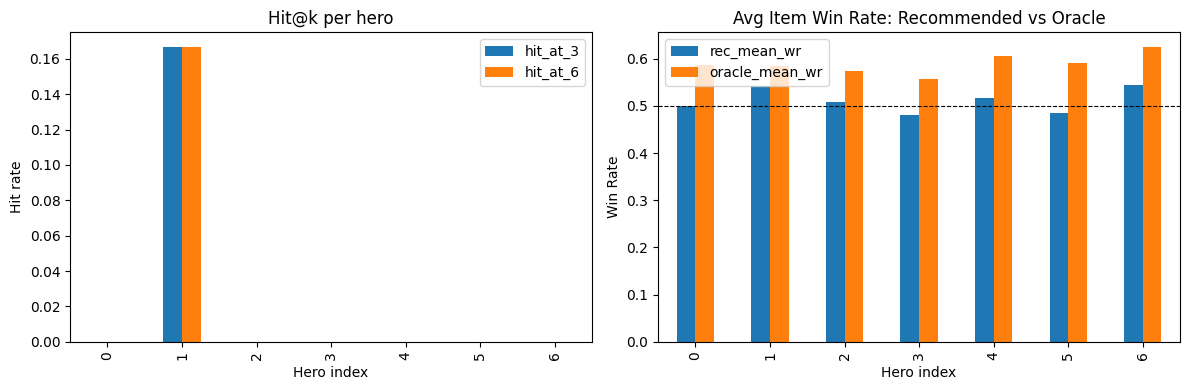

In [27]:
# ── Summary metrics ──────────────────────────────────────────────────────────
print("=" * 50)
print(f"Evaluation Summary — {RANK_TIER} rank tier")
print("=" * 50)
print(f"Hit@3 (model vs oracle):  {eval_df['hit_at_3'].mean():.3f}")
print(f"Hit@6 (model vs oracle):  {eval_df['hit_at_6'].mean():.3f}")
print(f"Avg recommended WR:       {eval_df['rec_mean_wr'].mean():.3f}")
print(f"Avg oracle WR:            {eval_df['oracle_mean_wr'].mean():.3f}")
print()
print("Note: Hit@k measures overlap with the oracle, not true win rate.")
print("High recommended WR vs. oracle WR = model finds alternative strong builds.")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
eval_df[["hit_at_3", "hit_at_6"]].plot.bar(ax=axes[0])
axes[0].set_title("Hit@k per hero")
axes[0].set_xlabel("Hero index")
axes[0].set_ylabel("Hit rate")

eval_df[["rec_mean_wr", "oracle_mean_wr"]].plot.bar(ax=axes[1])
axes[1].set_title("Avg Item Win Rate: Recommended vs Oracle")
axes[1].axhline(0.5, color="black", linestyle="--", linewidth=0.8)
axes[1].set_xlabel("Hero index")
axes[1].set_ylabel("Win Rate")

plt.tight_layout()
plt.show()

---
## 8. Next Steps & Extensions

| Idea | How |
|------|-----|
| **Conditional on opponent heroes** | Add an enemy team embedding using `hero-counters-stats` endpoint |
| **Economy-gated recommendations** | Use `net_worth_by_3000` bucket to make buy-time recommendations based on gold |
| **Patch-aware training** | Filter data by `min_unix_timestamp` per patch window and train separate embeddings |
| **Ability build joint model** | Co-train on `ability-order-stats` to recommend abilities + items together |
| **Transformer instead of GRU** | Replace GRU with a small causal Transformer for longer build horizons |
| **Offline RL fine-tuning** | Treat win/loss as reward and fine-tune with REINFORCE or DPO on high-WR sequences |
| **Live inference app** | Wrap inference with a FastAPI endpoint + Streamlit UI for real-time recommendations |
